# Churn 예측 모델링 - Baseline

이 노트북은 v2 데이터로 churn 예측의 기본 성능을 확인한다. 목표는 복잡한 튜닝보다 먼저 데이터 분리, 전처리, baseline 모델, threshold 조정, cluster label 추가 비교를 깔끔하게 검증하는 것이다.

핵심 원칙은 다음과 같다.

- 타겟은 `churned`, 식별자인 `user_id`는 제외한다.
- train/test split은 `stratify=y`, `random_state=42`로 고정한다.
- 수치형은 `StandardScaler`, 범주형은 `OneHotEncoder`로 처리한다.
- accuracy보다 recall, f1, PR AUC를 우선한다.
- cluster label은 train 데이터에서만 KMeans를 fit하고 test에는 predict만 적용한다.

## 1. 라이브러리 로드

기본 모델링에 필요한 라이브러리를 불러온다. `OneHotEncoder`는 scikit-learn 버전 차이를 흡수하기 위해 작은 helper 함수로 생성한다.

In [1]:
from pathlib import Path
import warnings

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE = 0.2

font_candidates = ['AppleGothic', 'NanumGothic', 'Malgun Gothic']
available_fonts = {font.name for font in fm.fontManager.ttflist}
font_name = next((font for font in font_candidates if font in available_fonts), None)
if font_name:
    plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')


def make_ohe(**kwargs):
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False, **kwargs)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False, **kwargs)

## 2. 데이터 로드

분석 대상은 `netflix_user_behavior_churn_50000v2.csv`다. 프로젝트 루트와 `notebooks/` 실행 위치를 모두 지원한다.

In [2]:
data_candidates = [
    Path('data/user_behavior_50000/netflix_user_behavior_churn_50000v2.csv'),
    Path('../data/user_behavior_50000/netflix_user_behavior_churn_50000v2.csv'),
]
data_path = next(path for path in data_candidates if path.exists())

df = pd.read_csv(data_path)
print(f'Data path: {data_path}')
print(f'Shape: {df.shape}')
df.head()

Data path: data/user_behavior_50000/netflix_user_behavior_churn_50000v2.csv
Shape: (50000, 20)


,user_id,age,gender,region,subscription_type,payment_method,primary_device,account_age_months,favorite_genre,time_of_day,recommendation_source,session_count,avg_watch_time_minutes_per_week,watch_sessions_per_week,completion_rate,avg_rating_given,app_rating,recommendation_click_rate,days_since_last_login,churned
0,N00001,33,Male,Europe,Basic,Credit Card,Smart TV,38,Comedy,Afternoon,Trending,1,259,4,79,4,4,48,3,0
1,N00002,41,Male,Africa,Premium,Credit Card,Tablet,49,Comedy,Evening,Search,1,164,4,69,4,4,32,30,0
2,N00003,28,Female,Europe,Standard,Gift Card,Laptop,20,Drama,Evening,Ads,1,304,5,75,4,3,31,5,1
3,N00004,40,Female,North America,Basic,Credit Card,Mobile,19,Action,Evening,Algorithm,1,145,6,79,4,4,39,38,0
4,N00005,54,Male,Europe,Standard,Paypal,Mobile,51,Romance,Evening,Friend,3,108,1,58,5,4,50,5,0


In [3]:
display(df.info())
display(df['churned'].value_counts().rename('count').to_frame())
display(df['churned'].value_counts(normalize=True).rename('ratio').to_frame())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   user_id                          50000 non-null  str  
 1   age                              50000 non-null  int64
 2   gender                           50000 non-null  str  
 3   region                           50000 non-null  str  
 4   subscription_type                50000 non-null  str  
 5   payment_method                   50000 non-null  str  
 6   primary_device                   50000 non-null  str  
 7   account_age_months               50000 non-null  int64
 8   favorite_genre                   50000 non-null  str  
 9   time_of_day                      50000 non-null  str  
 10  recommendation_source            50000 non-null  str  
 11  session_count                    50000 non-null  int64
 12  avg_watch_time_minutes_per_week  50000 non-null  int64
 1

None

,count
churned,
0,39536
1,10464


,ratio
churned,
0,0.79072
1,0.20928


**데이터 상태 해석**

- 결측치는 없고, `user_id`와 `churned`를 제외하면 모델 입력 피처는 18개다.
- 양성 클래스인 이탈 고객 비율은 약 20.9%다. 심한 불균형까지는 아니지만, 유지 고객이 약 79.1%이므로 accuracy 중심 평가는 위험하다.
- 이후 평가는 이탈 고객을 얼마나 잘 잡는지에 초점을 맞춰 recall, f1, PR AUC를 함께 본다.

## 3. 피처/타겟 분리와 Split

`user_id`는 식별자라 예측 피처에서 제외한다. churn 비율이 train/test에 비슷하게 유지되도록 stratified split을 사용한다.

In [4]:
target_col = 'churned'
id_col = 'user_id'

X = df.drop(columns=[id_col, target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Train churn ratio:', round(y_train.mean(), 4))
print('Test churn ratio:', round(y_test.mean(), 4))
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Train shape: (40000, 18) Test shape: (10000, 18)
Train churn ratio: 0.2093
Test churn ratio: 0.2093
Numeric features: ['age', 'account_age_months', 'session_count', 'avg_watch_time_minutes_per_week', 'watch_sessions_per_week', 'completion_rate', 'avg_rating_given', 'app_rating', 'recommendation_click_rate', 'days_since_last_login']
Categorical features: ['gender', 'region', 'subscription_type', 'payment_method', 'primary_device', 'favorite_genre', 'time_of_day', 'recommendation_source']


## 4. 전처리와 평가 함수

전처리와 모델을 하나의 `Pipeline`으로 묶어 train 데이터에만 fit되도록 한다. 평가에서는 accuracy도 보되, 최종 판단은 recall, f1, PR AUC 중심으로 한다.

In [5]:
def build_preprocessor(numeric_cols, categorical_cols):
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', make_ohe(), categorical_cols),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )


def get_scores(model, X_eval):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_eval)[:, 1]
    if hasattr(model, 'decision_function'):
        raw_scores = model.decision_function(X_eval)
        return (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
    return model.predict(X_eval)


def evaluate_predictions(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
    }


def evaluate_model(name, model, X_eval, y_eval, threshold=0.5):
    y_score = get_scores(model, X_eval)
    metrics = evaluate_predictions(y_eval, y_score, threshold=threshold)
    row = {k: v for k, v in metrics.items() if k != 'confusion_matrix'}
    row['model'] = name
    return row, metrics['confusion_matrix'], y_score


def show_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Pred 0', 'Pred 1'],
        yticklabels=['Actual 0', 'Actual 1'],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.show()

base_preprocessor = build_preprocessor(numeric_features, categorical_features)

## 5. Baseline 모델

먼저 세 모델을 비교한다.

- `DummyClassifier`: 최소 기준선
- `LogisticRegression`: 선형 모델 기준선
- `RandomForestClassifier`: 비선형 tree ensemble 기준선

불균형을 고려해 Logistic Regression과 Random Forest에는 `class_weight='balanced'`를 적용한다.

In [6]:
baseline_models = {
    'DummyClassifier': DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    ),
    'RandomForestClassifier': RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

fitted_models = {}
result_rows = []
confusions = {}
scores = {}

for name, estimator in baseline_models.items():
    pipe = Pipeline([
        ('preprocess', clone(base_preprocessor)),
        ('model', estimator),
    ])
    pipe.fit(X_train, y_train)
    row, cm, y_score = evaluate_model(name, pipe, X_test, y_test)
    fitted_models[name] = pipe
    result_rows.append(row)
    confusions[name] = cm
    scores[name] = y_score

baseline_result = pd.DataFrame(result_rows).set_index('model')
baseline_result.sort_values(['pr_auc', 'f1', 'recall'], ascending=False)

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
LogisticRegression,0.5,0.8331,0.570385,0.820831,0.673066,0.906524,0.763072
RandomForestClassifier,0.5,0.8693,0.693596,0.672719,0.682998,0.898237,0.744421
DummyClassifier,0.5,0.7907,0.000000,0.000000,0.000000,0.500000,0.209300


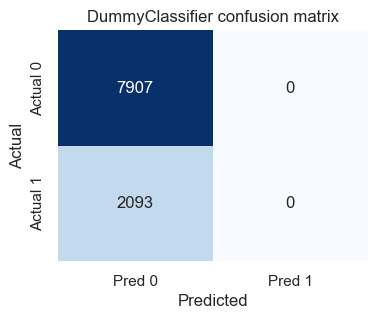

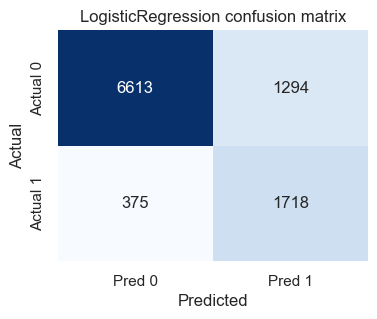

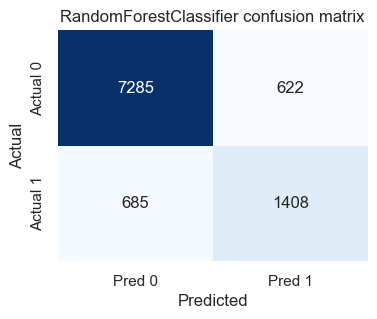

In [7]:
for name, cm in confusions.items():
    show_confusion_matrix(cm, f'{name} confusion matrix')

**Baseline 결과 해석**

- 전체 50,000명 중 churned=1 비율은 약 20.9%로, 다수 클래스인 유지 고객이 훨씬 많다. 따라서 단순 accuracy만 보면 모델을 잘못 평가할 수 있다.
- `DummyClassifier`는 모든 고객을 유지로 예측해 accuracy는 0.7907이지만, recall과 f1이 0이다. 이 모델은 이탈자를 한 명도 잡지 못하므로 실제 churn 예측 모델로는 의미가 없다.
- `LogisticRegression`은 recall 0.8208, PR AUC 0.7631로 가장 좋은 양성 클래스 탐지력을 보였다. 이탈 가능 고객을 넓게 잡아내는 목적에는 가장 적합하다.
- `RandomForestClassifier`는 accuracy 0.8693, precision 0.6936, f1 0.6830으로 기본 threshold에서는 균형이 좋다. 다만 recall 0.6727, PR AUC 0.7444로 이탈자를 놓치는 비율은 Logistic Regression보다 크다.
- 이 프로젝트에서는 accuracy보다 recall, f1, PR AUC를 우선하므로, baseline 단계의 핵심 후보는 Logistic Regression과 Random Forest다.


## 6. 기본 부스팅 모델

튜닝 전 단계에서 LightGBM을 우선 사용한다. 설치 문제가 있으면 XGBoost, CatBoost 순서로 실행 가능한 모델을 선택한다. 세부 튜닝은 `05_churn_modeling_tuning_ensemble.ipynb`에서 따로 진행한다.

In [8]:
def make_boosting_candidates(y_train):
    candidates = []

    try:
        from lightgbm import LGBMClassifier
        candidates.append(('LightGBM', LGBMClassifier(
            n_estimators=400,
            learning_rate=0.04,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )))
    except Exception as exc:
        print('LightGBM unavailable:', exc)

    try:
        from xgboost import XGBClassifier
        neg, pos = np.bincount(y_train)
        candidates.append(('XGBoost', XGBClassifier(
            n_estimators=400,
            learning_rate=0.04,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric='logloss',
            scale_pos_weight=neg / pos,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )))
    except Exception as exc:
        print('XGBoost unavailable:', exc)

    try:
        from catboost import CatBoostClassifier
        candidates.append(('CatBoost', CatBoostClassifier(
            iterations=400,
            learning_rate=0.04,
            depth=6,
            loss_function='Logloss',
            auto_class_weights='Balanced',
            random_seed=RANDOM_STATE,
            verbose=False,
        )))
    except Exception as exc:
        print('CatBoost unavailable:', exc)

    return candidates

boosting_rows = []
for name, estimator in make_boosting_candidates(y_train):
    pipe = Pipeline([
        ('preprocess', clone(base_preprocessor)),
        ('model', estimator),
    ])
    try:
        pipe.fit(X_train, y_train)
        row, cm, y_score = evaluate_model(name, pipe, X_test, y_test)
        fitted_models[name] = pipe
        boosting_rows.append(row)
        confusions[name] = cm
        scores[name] = y_score
    except Exception as exc:
        print(f'{name} failed:', exc)

boosting_result = pd.DataFrame(boosting_rows).set_index('model')
all_model_result = pd.concat([baseline_result, boosting_result], axis=0)
all_model_result.sort_values(['pr_auc', 'f1', 'recall'], ascending=False)

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
LogisticRegression,0.5,0.8331,0.570385,0.820831,0.673066,0.906524,0.763072
CatBoost,0.5,0.8372,0.578894,0.815098,0.676984,0.905449,0.761781
XGBoost,0.5,0.8330,0.571380,0.808887,0.669699,0.903804,0.760384
LightGBM,0.5,0.8382,0.582839,0.798376,0.673790,0.902313,0.756347
RandomForestClassifier,0.5,0.8693,0.693596,0.672719,0.682998,0.898237,0.744421
DummyClassifier,0.5,0.7907,0.000000,0.000000,0.000000,0.500000,0.209300


Best baseline-stage model: LogisticRegression


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
LogisticRegression,0.5,0.8331,0.570385,0.820831,0.673066,0.906524,0.763072


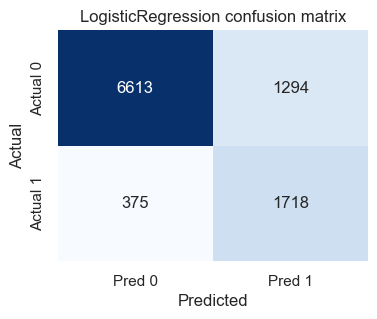

In [9]:
best_model_name = all_model_result.sort_values(['pr_auc', 'f1', 'recall'], ascending=False).index[0]
best_model = fitted_models[best_model_name]
best_scores = scores[best_model_name]

print('Best baseline-stage model:', best_model_name)
display(all_model_result.loc[[best_model_name]])
show_confusion_matrix(confusions[best_model_name], f'{best_model_name} confusion matrix')

**부스팅 모델 포함 결과 해석**

- LightGBM, XGBoost, CatBoost를 추가했지만, 기본 설정 기준에서는 Logistic Regression이 PR AUC 0.7631로 가장 높았다.
- CatBoost는 PR AUC 0.7618, recall 0.8151로 Logistic Regression과 매우 근접했다. 다만 이 단계에서는 복잡한 모델을 선택할 만큼의 명확한 개선은 없다.
- Random Forest는 f1이 0.6830으로 기본 threshold 기준에서는 높지만, PR AUC와 recall은 Logistic Regression보다 낮다.
- 따라서 `04`의 baseline 결론은 Logistic Regression을 중심 후보로 두고, `05`에서 CatBoost/LightGBM/XGBoost 튜닝과 앙상블을 추가 확인하는 흐름이 자연스럽다.

## 7. Threshold 조정

기본 threshold 0.5가 최선이라고 가정하지 않는다. 이탈 예측에서는 threshold를 낮춰 recall을 높이는 선택이 더 적절할 수 있다. 단, recall을 높이면 precision은 낮아질 수 있으므로 f1과 함께 본다.

In [10]:
def make_threshold_table(y_true, y_score, thresholds=np.arange(0.05, 0.96, 0.01)):
    rows = []
    for threshold in thresholds:
        row = evaluate_predictions(y_true, y_score, threshold=threshold)
        rows.append({k: v for k, v in row.items() if k != 'confusion_matrix'})
    return pd.DataFrame(rows)

threshold_result = make_threshold_table(y_test, best_scores)
best_f1_row = threshold_result.loc[threshold_result['f1'].idxmax()]

recall_target = 0.70
recall_candidates = threshold_result[threshold_result['recall'] >= recall_target]
best_recall_row = recall_candidates.loc[recall_candidates['f1'].idxmax()] if len(recall_candidates) else best_f1_row

print('Best F1 threshold')
display(best_f1_row.to_frame().T)
print(f'Best threshold with recall >= {recall_target}')
display(best_recall_row.to_frame().T)

Best F1 threshold


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
59,0.64,0.8658,0.661228,0.735786,0.696517,0.906524,0.763072


Best threshold with recall >= 0.7


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
59,0.64,0.8658,0.661228,0.735786,0.696517,0.906524,0.763072


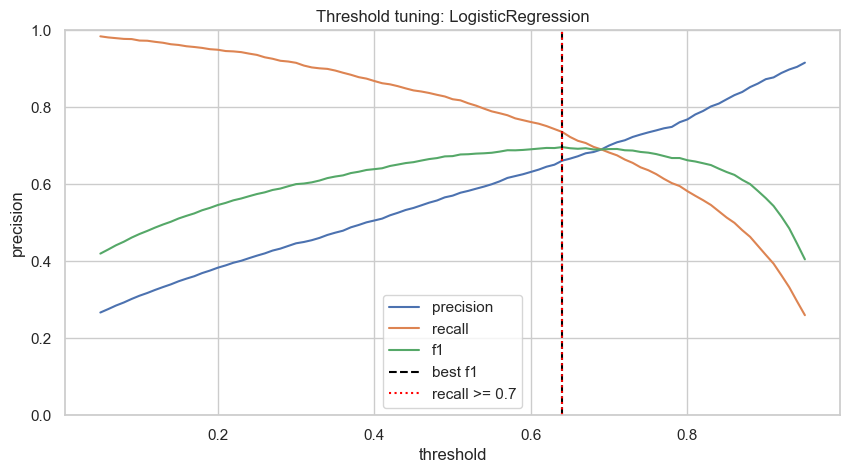

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.64,0.8658,0.661228,0.735786,0.696517,0.906524,0.763072


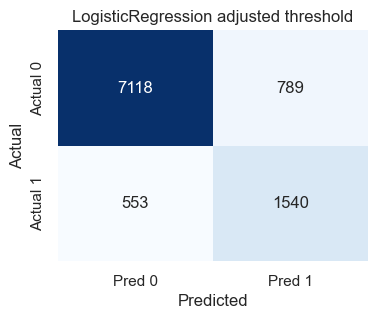

In [11]:
plt.figure(figsize=(10, 5))
for metric in ['precision', 'recall', 'f1']:
    sns.lineplot(data=threshold_result, x='threshold', y=metric, label=metric)
plt.axvline(best_f1_row['threshold'], color='black', linestyle='--', label='best f1')
plt.axvline(best_recall_row['threshold'], color='red', linestyle=':', label=f'recall >= {recall_target}')
plt.ylim(0, 1)
plt.title(f'Threshold tuning: {best_model_name}')
plt.legend()
plt.show()

selected_threshold = float(best_recall_row['threshold'])
selected_metrics = evaluate_predictions(y_test, best_scores, threshold=selected_threshold)
display(pd.DataFrame([{k: v for k, v in selected_metrics.items() if k != 'confusion_matrix'}]))
show_confusion_matrix(selected_metrics['confusion_matrix'], f'{best_model_name} adjusted threshold')

**Threshold 조정 결과 해석**

- 기본 threshold 0.5에서 Logistic Regression은 recall 0.8208로 이탈자를 넓게 잡지만, precision 0.5704로 오탐도 많은 편이다.
- threshold를 0.64로 올리면 recall은 0.7358로 낮아지지만, precision은 0.6612로 개선되고 f1은 0.6731에서 0.6965로 상승한다.
- 즉, threshold 0.64는 “이탈자를 최대한 많이 잡기”보다 “실제 캠페인 대상의 품질과 탐지율 균형”에 더 적합하다.
- 만약 이탈 방지 캠페인 비용이 낮고 더 많은 고객에게 개입해도 된다면 threshold를 0.64보다 낮춰 recall을 더 높이는 선택도 가능하다.

## 8. Feature Importance

모델이 어떤 변수를 중요하게 사용했는지 확인한다. tree 계열 모델이면 내장 중요도를 사용하고, 그렇지 않으면 permutation importance를 사용한다. 중요도는 인과관계가 아니라 모델의 예측 근거에 가깝다.

,feature,importance
9,days_since_last_login,0.260808
3,avg_watch_time_minutes_per_week,0.033045
18,subscription_type_Basic,0.022354
21,payment_method_Credit Card,0.020068
27,primary_device_Smart TV,0.016649
19,subscription_type_Premium,0.015839
0,age,0.015623
5,completion_rate,0.013919
8,recommendation_click_rate,0.013486
7,app_rating,0.009091


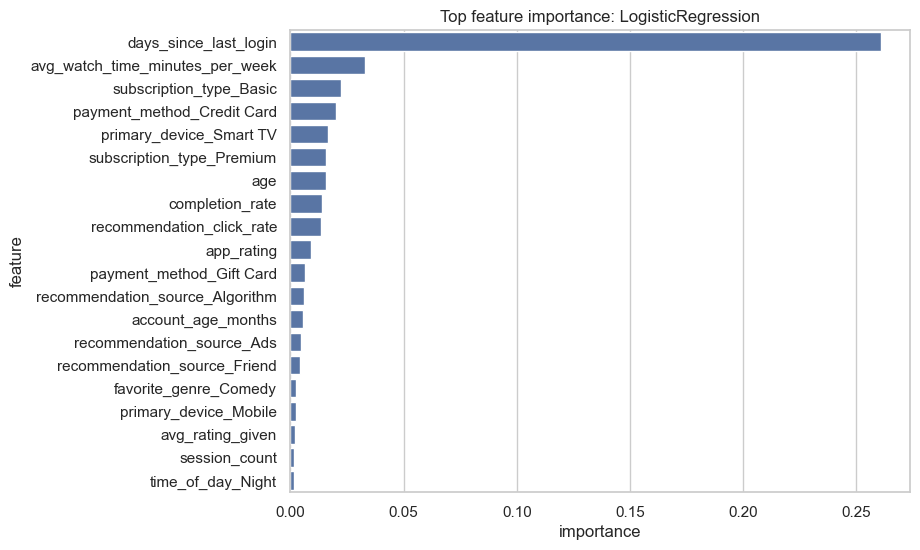

In [12]:
def get_feature_names(fitted_pipeline):
    preprocessor = fitted_pipeline.named_steps['preprocess']
    try:
        return preprocessor.get_feature_names_out().tolist()
    except Exception:
        names = []
        names.extend(numeric_features)
        ohe = preprocessor.named_transformers_['cat']
        names.extend(ohe.get_feature_names_out(categorical_features).tolist())
        return names

feature_names = get_feature_names(best_model)
estimator = best_model.named_steps['model']

if hasattr(estimator, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': estimator.feature_importances_,
    })
else:
    transformed_test = best_model.named_steps['preprocess'].transform(X_test)
    perm = permutation_importance(
        estimator,
        transformed_test,
        y_test,
        scoring='average_precision',
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': perm.importances_mean,
    })

importance_df = importance_df.sort_values('importance', ascending=False)
display(importance_df.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(20), x='importance', y='feature')
plt.title(f'Top feature importance: {best_model_name}')
plt.show()

**Feature Importance 해석**

- 가장 중요한 변수는 `days_since_last_login`이다. 최근 로그인하지 않은 기간이 churn 예측에서 핵심 신호로 작동한다.
- `avg_watch_time_minutes_per_week`, `completion_rate`, `recommendation_click_rate`, `app_rating`처럼 서비스 이용 강도와 만족도에 가까운 변수도 상위권에 있다.
- `subscription_type_Basic`, `payment_method_Credit Card`, `primary_device_Smart TV` 등 일부 범주형 값도 중요하게 나타난다. 다만 One-Hot 변수의 중요도는 해당 값 하나의 효과로 쪼개져 보이므로, 원본 컬럼 단위 해석과 함께 보는 것이 좋다.
- 중요도는 인과관계가 아니라 예측에 사용된 신호다. 예를 들어 `days_since_last_login`이 높아서 이탈이 발생했다고 단정하기보다, 이 변수가 이탈 직전 행동을 잘 포착한다고 해석하는 편이 안전하다.

## 9. Cluster Label 추가 비교

군집화 결과를 모델 피처로 활용한다. 단, 전체 데이터로 군집을 fit하면 test 정보가 군집 중심에 반영되므로 누수가 된다. 여기서는 train 데이터에서만 군집용 전처리기와 KMeans를 fit하고, test에는 predict만 적용한다.

In [13]:
cluster_feature_cols = [
    'age',
    'account_age_months',
    'subscription_type',
    'payment_method',
    'primary_device',
    'favorite_genre',
    'time_of_day',
    'recommendation_source',
    'session_count',
    'avg_watch_time_minutes_per_week',
    'watch_sessions_per_week',
    'completion_rate',
    'avg_rating_given',
    'app_rating',
    'recommendation_click_rate',
    'days_since_last_login',
]

cluster_numeric_features = X_train[cluster_feature_cols].select_dtypes(include='number').columns.tolist()
cluster_categorical_features = X_train[cluster_feature_cols].select_dtypes(include=['object', 'string', 'category']).columns.tolist()

cluster_preprocessor = build_preprocessor(cluster_numeric_features, cluster_categorical_features)
X_train_cluster_matrix = cluster_preprocessor.fit_transform(X_train[cluster_feature_cols])
X_test_cluster_matrix = cluster_preprocessor.transform(X_test[cluster_feature_cols])

SELECTED_K = 3
kmeans = KMeans(n_clusters=SELECTED_K, random_state=RANDOM_STATE, n_init=10)
train_cluster_labels = kmeans.fit_predict(X_train_cluster_matrix)
test_cluster_labels = kmeans.predict(X_test_cluster_matrix)

X_train_with_cluster = X_train.copy()
X_test_with_cluster = X_test.copy()
X_train_with_cluster['cluster'] = train_cluster_labels.astype(str)
X_test_with_cluster['cluster'] = test_cluster_labels.astype(str)

cluster_summary = pd.DataFrame({
    'cluster': train_cluster_labels,
    'churned': y_train.to_numpy(),
}).groupby('cluster').agg(users=('churned', 'size'), churn_rate=('churned', 'mean'))
cluster_summary

,users,churn_rate
cluster,,
0,8177,0.021401
1,11749,0.537833
2,20074,0.093504


**Train 기준 군집 해석**

- KMeans는 train 데이터에서만 fit했고, 이 결과 train 고객은 3개 군집으로 나뉜다.
- cluster 1은 churn rate가 약 53.8%로 매우 높은 고위험군이다.
- cluster 0은 churn rate가 약 2.1%로 매우 낮은 안정 고객군이고, cluster 2는 약 9.4%로 중간보다 낮은 유지 성향 고객군이다.
- 군집 자체는 churned를 사용하지 않고 만들었는데도 churn rate 차이가 크다. 이는 사용 행동 조합이 이탈 위험을 잘 구분하고 있음을 보여준다.

In [14]:
cluster_numeric_model = X_train_with_cluster.select_dtypes(include='number').columns.tolist()
cluster_categorical_model = X_train_with_cluster.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
cluster_model_preprocessor = build_preprocessor(cluster_numeric_model, cluster_categorical_model)

cluster_label_model = Pipeline([
    ('preprocess', cluster_model_preprocessor),
    ('model', clone(best_model.named_steps['model'])),
])
cluster_label_model.fit(X_train_with_cluster, y_train)

cluster_row, cluster_cm, cluster_score = evaluate_model(
    f'{best_model_name} + cluster',
    cluster_label_model,
    X_test_with_cluster,
    y_test,
)

metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
comparison = pd.DataFrame([
    {'model': best_model_name, **all_model_result.loc[best_model_name].to_dict()},
    cluster_row,
]).set_index('model')
comparison[metric_cols + ['threshold']].sort_values(['pr_auc', 'f1', 'recall'], ascending=False)

,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold
model,,,,,,,
LogisticRegression,0.8331,0.570385,0.820831,0.673066,0.906524,0.763072,0.5
LogisticRegression + cluster,0.8336,0.571381,0.820354,0.673597,0.906364,0.762790,0.5


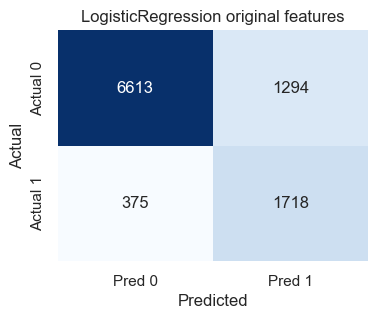

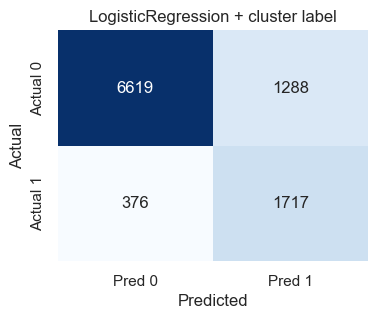

,cluster_label_gain
accuracy,0.000500
precision,0.000996
recall,-0.000478
f1,0.000532
roc_auc,-0.000160
pr_auc,-0.000281


In [15]:
show_confusion_matrix(confusions[best_model_name], f'{best_model_name} original features')
show_confusion_matrix(cluster_cm, f'{best_model_name} + cluster label')

cluster_gain = comparison.loc[f'{best_model_name} + cluster', metric_cols] - comparison.loc[best_model_name, metric_cols]
cluster_gain.rename('cluster_label_gain').to_frame()

**Cluster Label 추가 모델 해석**

- cluster label을 추가한 모델은 accuracy와 f1이 아주 작게 상승했지만, recall, ROC AUC, PR AUC는 소폭 하락했다.
- PR AUC 기준으로는 0.7631에서 0.7628로 거의 차이가 없고, 개선이라고 보기 어렵다.
- 결론적으로 군집은 고객군 해석에는 유용하지만, 현재 Logistic Regression 예측 성능을 의미 있게 끌어올리지는 못했다.
- 따라서 `04`의 모델링 결론에서는 원본 피처 기반 Logistic Regression을 기준 모델로 두고, cluster label은 “해석용 세그먼트” 또는 `05`의 추가 실험 후보로 다루는 것이 적절하다.

## 10. 정리

`04`의 baseline 모델링 결과는 다음과 같이 정리할 수 있다.

- v2 데이터의 churn 비율은 약 20.9%이며, accuracy만으로는 모델 품질을 판단하기 어렵다.
- 기본 모델 중 Logistic Regression은 recall 0.8208, PR AUC 0.7631로 이탈 고객 탐지에 가장 강했다.
- Random Forest는 기본 threshold에서 f1이 높지만, 이탈 고객을 넓게 잡는 능력은 Logistic Regression보다 약했다.
- 부스팅 모델은 기본 설정에서 Logistic Regression을 명확히 넘지 못했다. CatBoost는 매우 근접하므로 `05`에서 튜닝 후보로 볼 만하다.
- threshold를 0.64로 조정하면 Logistic Regression의 f1이 0.6965로 개선된다. 이 값은 precision과 recall의 균형을 고려한 실무 기준점으로 사용할 수 있다.
- KMeans cluster label은 고객군 해석에는 유용했지만, 예측 성능 개선은 거의 없었다.

따라서 `04`의 기준 모델은 원본 피처 기반 Logistic Regression으로 두고, `05`에서는 CatBoost/LightGBM/XGBoost 튜닝, Soft Voting, Stacking이 이 기준선을 실질적으로 넘는지 검증한다.
